# SAR-Assisted Land-Cover Understanding under Degraded Optical Conditions

**Case study:** investigate whether Sentinel-1 SAR provides useful information when Sentinel-2
optical observations are partially unavailable (cloud-obscured).

## Problem formulation

Multi-label land-cover classification on paired Sentinel-1/Sentinel-2 patches from
**BigEarthNet v2.0 (reBEN)**, evaluated under three conditions:

| Condition | Input | Model |
|---|---|---|
| **A. Optical only** | clean Sentinel-2 (12 bands) | CNN trained on clean optical |
| **B. Degraded optical** | Sentinel-2 with simulated cloud masks | same CNN (baseline), + a variant trained with mask augmentation |
| **C. Degraded optical + SAR** | masked Sentinel-2 ⊕ Sentinel-1 (VV, VH) | same CNN with 14 input channels (early fusion by channel concatenation) |

The **scientific comparison is B vs C**: models share the identical architecture, training
regime, random seed, and — crucially — see *pixel-identical* deterministic cloud masks at
evaluation. The only difference is whether the 2 SAR channels are appended.

## Dataset (external resources — documented per instructions)

- [`hackelle/BigEarthNetV2-Lithuania-Summer-LMDB`](https://huggingface.co/datasets/hackelle/BigEarthNetV2-Lithuania-Summer-LMDB) —
  an LMDB conversion of the official **BigEarthNet v2.0 (reBEN)** subset (Lithuania, summer
  acquisitions), published by a member of the original BigEarthNet team (TU Berlin RSiM).
  8,775 paired S1/S2 patches (~2.5 GB), official train/validation/test splits, 19-class label set.
- Original dataset: Clasen et al., *"reBEN: Refined BigEarthNet Dataset for Remote Sensing Image Analysis"*, 2024.
- Libraries: PyTorch, numpy, pandas, scikit-learn, scipy, matplotlib, lmdb, safetensors, huggingface_hub.

**Known limitations of this subset (discussed at the end):** single country and season →
reduced class diversity; BigEarthNet labels are scene-level (multi-label, from CORINE 2018) and
inherently noisy; simulated masks are an approximation of real cloud cover.


## 1. Setup

Reproducibility: one global seed controls Python/NumPy/PyTorch and every mask we generate.
Evaluation masks are additionally derived from *per-patch* seeds so they are identical across
models and across notebook re-runs.


In [1]:
import json, math, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import ndimage
from sklearn.metrics import f1_score, average_precision_score, precision_score, recall_score
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'CPU')

DATA_DIR = Path('data/BENv2_lithuania_summer')
PROC_DIR = Path('data/processed'); PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR  = Path('figures');        FIG_DIR.mkdir(exist_ok=True)

PATCH = 120                       # patch size (pixels) after upsampling all bands to 10 m grid
S2_BANDS = ['B01','B02','B03','B04','B05','B06','B07','B08','B8A','B09','B11','B12']
S1_BANDS = ['VV','VH']

# Simulated cloud-coverage levels used for evaluation (1.0 = optical fully lost -> SAR only)
MASK_LEVELS = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]

# Training hyperparameters (deliberately not tuned, per the case-study instructions)
EPOCHS, BATCH, LR, WD = 30, 64, 1e-3, 1e-4


C:\Users\varun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Data acquisition

Downloads the LMDB + metadata (~2.5 GB) from HuggingFace. Idempotent — skipped if files exist.


In [2]:
from huggingface_hub import snapshot_download

snapshot_download(repo_id='hackelle/BigEarthNetV2-Lithuania-Summer-LMDB',
                  repo_type='dataset', local_dir=DATA_DIR)

LMDB_PATH = DATA_DIR / 'BENv2_lithuania_summer.lmdb'
META_PATH = DATA_DIR / 'metadata_lithuania_summer.parquet'
for p in [LMDB_PATH, META_PATH]:
    assert p.exists(), f'missing {p}'
print('download OK:', sum(f.stat().st_size for f in DATA_DIR.rglob("*") if f.is_file()) / 1e9, 'GB')


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 103.77it/s]

download OK: 2.482130577 GB


## 3. Data inspection & cleaning

Before modelling: understand splits, label structure, and verify the data is what we think it is.
Patches flagged `contains_cloud_or_shadow` or `contains_seasonal_snow` would confound our
*controlled* degradation experiment — we check and drop them (this subset ships with zero, i.e.
the optical patches are clean, which is exactly what we want as the "clean optical" reference).


(8775, 8)
['patch_id', 'labels', 'split', 'country', 's1_name', 's2v1_name', 'contains_seasonal_snow', 'contains_cloud_or_shadow']


,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
39329,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_54,S2A_MSIL2A_20170720T100031_61_54,False,False
39330,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_55,S2A_MSIL2A_20170720T100031_61_55,False,False
39331,S2A_MSIL2A_20170720T100031_N9999_R122_T34UDG_6...,[Marine waters],test,Lithuania,S1B_IW_GRDH_1SDV_20170719T045054_34UDG_61_56,S2A_MSIL2A_20170720T100031_61_56,False,False



split counts:
split
train         4206
validation    2418
test          2151
Name: count, dtype: int64

naturally cloudy patches: 0 | snowy: 0


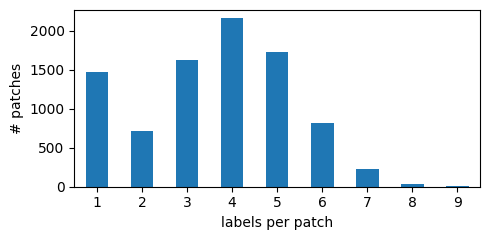

labels
Complex cultivation patterns                                                              4449
Mixed forest                                                                              4174
Coniferous forest                                                                         3862
Arable land                                                                               3738
Land principally occupied by agriculture, with significant areas of natural vegetation    3372
Pastures                                                                                  2981
Transitional woodland, shrub                                                              2588
Broad-leaved forest                                                                       1923
Marine waters                                                                             1432
Urban fabric                                                                              1270
Inland waters                              

In [3]:
meta = pd.read_parquet(META_PATH)
print(meta.shape); print(meta.columns.tolist())
display(meta.head(3))

print('\nsplit counts:'); print(meta['split'].value_counts())
print('\nnaturally cloudy patches:', int(meta['contains_cloud_or_shadow'].sum()),
      '| snowy:', int(meta['contains_seasonal_snow'].sum()))
meta = meta[~meta['contains_cloud_or_shadow'] & ~meta['contains_seasonal_snow']].reset_index(drop=True)

meta['n_labels'] = meta['labels'].apply(len)
ax = meta['n_labels'].value_counts().sort_index().plot.bar(figsize=(5,2.5), rot=0)
ax.set_xlabel('labels per patch'); ax.set_ylabel('# patches'); plt.tight_layout(); plt.show()

freq = meta.explode('labels')['labels'].value_counts()
print(freq.to_string())


### Label space

Patches carry 1–9 of the 19 BigEarthNet classes (median ≈ 4) → this is a **multi-label**
problem. We keep the **11 classes with ≥ 1,000 positive patches**; the remaining 6 rare classes
(< 350 patches, some < 100) cannot be learned or evaluated reliably from this subset and are
dropped from the label space. Patches are kept as long as they have ≥ 1 positive among the 11.


In [4]:
CLASSES = [
    'Urban fabric',
    'Arable land',
    'Pastures',
    'Complex cultivation patterns',
    'Land principally occupied by agriculture, with significant areas of natural vegetation',
    'Broad-leaved forest',
    'Coniferous forest',
    'Mixed forest',
    'Transitional woodland, shrub',
    'Inland waters',
    'Marine waters',
]
NC = len(CLASSES)
assert set(CLASSES) == set(freq[freq >= 1000].index), 'class list out of sync with data'

def to_multihot(labels):
    v = np.zeros(NC, dtype=np.float32)
    for l in labels:
        if l in CLASSES: v[CLASSES.index(l)] = 1.0
    return v

meta['y'] = meta['labels'].apply(to_multihot)
kept = meta['y'].apply(lambda v: v.sum() > 0)
print(f'dropping {int((~kept).sum())} patches with no positive label among the {NC} classes')
meta = meta[kept].reset_index(drop=True)

# per-split positive counts per class — check every class is represented everywhere
Y = np.stack(meta['y'])
tab = pd.DataFrame({s: Y[(meta['split'] == s).values].sum(0).astype(int)
                    for s in ['train', 'validation', 'test']}, index=CLASSES)
display(tab)
assert (tab > 20).all().all(), 'a class has too little support in some split'


dropping 1 patches with no positive label among the 11 classes


,train,validation,test
Urban fabric,620,385,265
Arable land,1714,1141,883
Pastures,1169,896,916
Complex cultivation patterns,1955,1322,1172
"Land principally occupied by agriculture, with significant areas of natural vegetation",1474,902,996
Broad-leaved forest,905,507,511
Coniferous forest,1782,887,1193
Mixed forest,1851,1109,1214
"Transitional woodland, shrub",1118,585,885
Inland waters,493,265,379


### Probing the LMDB — verify shapes, dtypes, value ranges

Sentinel-2 bands are stored at native resolution (10 m → 120², 20 m → 60², 60 m → 20²) as
reflectance `uint16`; Sentinel-1 as backscatter. We verify rather than assume.


In [5]:
import lmdb
from safetensors.numpy import load as st_load

env = lmdb.open(str(LMDB_PATH), readonly=True, lock=False, readahead=True, subdir=LMDB_PATH.is_dir())

with env.begin() as txn:
    row = meta.iloc[0]
    s2 = st_load(bytes(txn.get(row['patch_id'].encode())))
    s1 = st_load(bytes(txn.get(row['s1_name'].encode())))

for k in sorted(s2): print(f'S2 {k}: {s2[k].shape} {s2[k].dtype}  range [{s2[k].min()}, {s2[k].max()}]')
for k in sorted(s1): print(f'S1 {k}: {s1[k].shape} {s1[k].dtype}  range [{s1[k].min():.2f}, {s1[k].max():.2f}]')


S2 B01: (20, 20) uint16  range [255, 281]
S2 B02: (120, 120) uint16  range [171, 296]
S2 B03: (120, 120) uint16  range [210, 311]
S2 B04: (120, 120) uint16  range [94, 182]
S2 B05: (60, 60) uint16  range [87, 151]
S2 B06: (60, 60) uint16  range [57, 113]
S2 B07: (60, 60) uint16  range [49, 109]
S2 B08: (120, 120) uint16  range [45, 125]
S2 B09: (20, 20) uint16  range [40, 82]
S2 B11: (60, 60) uint16  range [27, 67]
S2 B12: (60, 60) uint16  range [14, 63]
S2 B8A: (60, 60) uint16  range [36, 98]
S1 VH: (120, 120) float32  range [-43.09, -20.47]
S1 VV: (120, 120) float32  range [-28.59, -11.23]


## 4. Preprocessing → memory-mapped arrays

One pass over the LMDB: upsample every band bilinearly to the 10 m grid (120×120), stack into
canonical order, store as `float16` memmaps (`X_opt [N,12,120,120]`, `X_sar [N,2,120,120]`).
~3.5 GB on disk, read back lazily; re-runs of the notebook skip this cell's work entirely.


In [6]:
X_OPT_P, X_SAR_P, IDX_P = PROC_DIR/'X_opt.npy', PROC_DIR/'X_sar.npy', PROC_DIR/'index.parquet'

def resample_to_patch(arr):
    t = torch.from_numpy(arr.astype(np.float32))[None, None]
    if t.shape[-1] != PATCH:
        t = F.interpolate(t, size=(PATCH, PATCH), mode='bilinear', align_corners=False)
    return t[0, 0].numpy()

if not (X_OPT_P.exists() and X_SAR_P.exists() and IDX_P.exists()):
    N = len(meta)
    X_opt = np.lib.format.open_memmap(X_OPT_P, mode='w+', dtype=np.float16, shape=(N, 12, PATCH, PATCH))
    X_sar = np.lib.format.open_memmap(X_SAR_P, mode='w+', dtype=np.float16, shape=(N, 2, PATCH, PATCH))
    with env.begin() as txn:
        for i, row in enumerate(tqdm(meta.itertuples(), total=N, desc='LMDB -> memmap')):
            s2 = st_load(bytes(txn.get(row.patch_id.encode())))
            s1 = st_load(bytes(txn.get(row.s1_name.encode())))
            X_opt[i] = np.stack([resample_to_patch(s2[b]) for b in S2_BANDS]).astype(np.float16)
            X_sar[i] = np.stack([resample_to_patch(s1[b]) for b in S1_BANDS]).astype(np.float16)
    X_opt.flush(); X_sar.flush()
    meta.drop(columns=['y']).to_parquet(IDX_P)   # y rebuilt from labels on load

X_opt = np.load(X_OPT_P, mmap_mode='r')
X_sar = np.load(X_SAR_P, mmap_mode='r')
idx_df = pd.read_parquet(IDX_P)
assert len(idx_df) == len(meta) and (idx_df['patch_id'].values == meta['patch_id'].values).all(), \
    'processed cache out of sync with metadata filter — delete data/processed and re-run'
print('X_opt', X_opt.shape, X_opt.dtype, '| X_sar', X_sar.shape, X_sar.dtype)

split_idx = {s: np.where((meta['split'] == s).values)[0] for s in ['train', 'validation', 'test']}
Y = np.stack(meta['y']).astype(np.float32)
print({k: len(v) for k, v in split_idx.items()})


X_opt (8774, 12, 120, 120) float16 | X_sar (8774, 2, 120, 120) float16
{'train': 4205, 'validation': 2418, 'test': 2151}


### Normalisation statistics (train split only — no leakage)

Per-band mean/std computed on the training split. Inputs are standardised; **masked pixels are
set to 0 after standardisation**, i.e. to the per-band mean — the least-informative value.
SAR backscatter is log-scaled dB-like; we standardise it with its own stats.


In [7]:
STATS_P = PROC_DIR / 'norm_stats.json'
if not STATS_P.exists():
    tr = split_idx['train']
    sample = tr[::3]                                   # every 3rd train patch is plenty for stats
    xo = X_opt[sample].astype(np.float32)
    xs = X_sar[sample].astype(np.float32)
    stats = {'opt_mean': xo.mean(axis=(0, 2, 3)).tolist(), 'opt_std': xo.std(axis=(0, 2, 3)).tolist(),
             'sar_mean': xs.mean(axis=(0, 2, 3)).tolist(), 'sar_std': xs.std(axis=(0, 2, 3)).tolist()}
    STATS_P.write_text(json.dumps(stats, indent=2)); del xo, xs
stats = json.loads(STATS_P.read_text())
OPT_MEAN = torch.tensor(stats['opt_mean']).view(1, 12, 1, 1)
OPT_STD  = torch.tensor(stats['opt_std']).view(1, 12, 1, 1)
SAR_MEAN = torch.tensor(stats['sar_mean']).view(1, 2, 1, 1)
SAR_STD  = torch.tensor(stats['sar_std']).view(1, 2, 1, 1)
pd.DataFrame({'band': S2_BANDS + S1_BANDS,
              'mean': stats['opt_mean'] + stats['sar_mean'],
              'std':  stats['opt_std'] + stats['sar_std']}).round(1)


,band,mean,std
0,B01,232.3,140.9
1,B02,306.5,192.0
2,B03,479.9,254.2
3,B04,372.7,330.9
4,B05,732.2,435.9
5,B06,1755.1,996.2
6,B07,2107.8,1214.4
7,B08,2268.5,1351.3
8,B8A,2304.7,1331.2
9,B09,2302.4,1290.1


### Visual sanity check — RGB composites and SAR


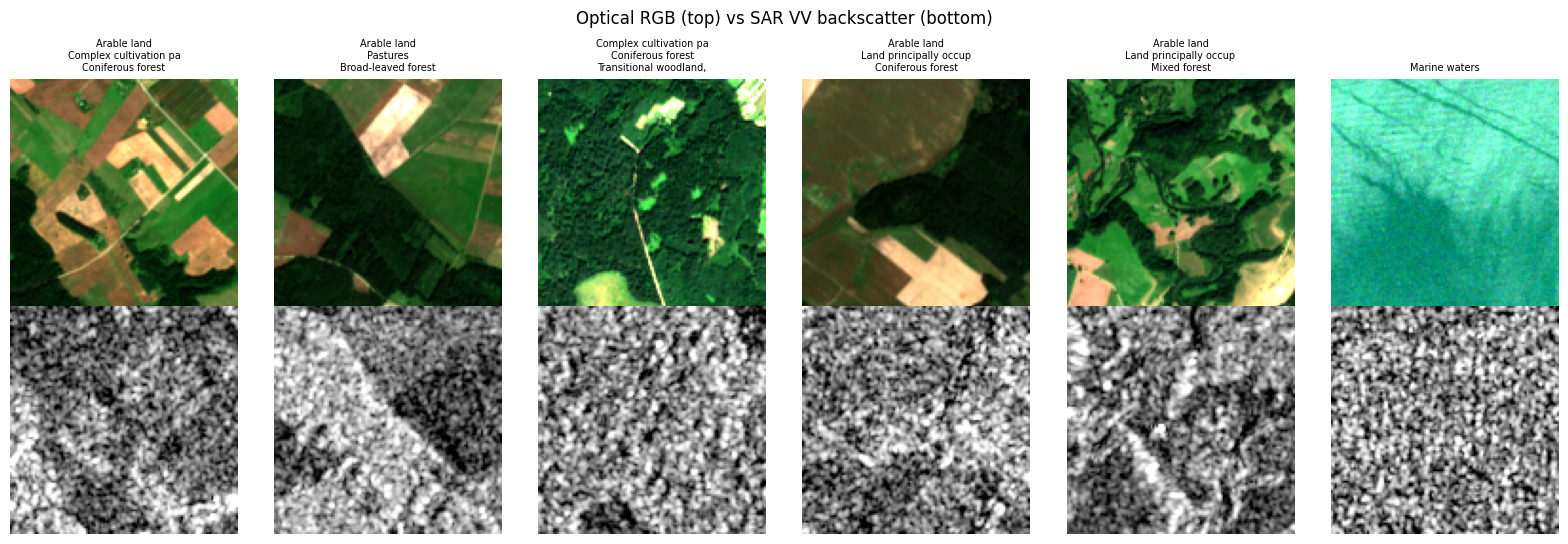

In [8]:
def rgb(i):
    x = X_opt[i, [3, 2, 1]].astype(np.float32)         # B04,B03,B02
    lo, hi = np.percentile(x, 2), np.percentile(x, 98)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1).transpose(1, 2, 0)

def sar_img(i, ch=0):
    x = X_sar[i, ch].astype(np.float32)
    lo, hi = np.percentile(x, 2), np.percentile(x, 98)
    return np.clip((x - lo) / (hi - lo + 1e-6), 0, 1)

rng = np.random.default_rng(SEED)
show = rng.choice(split_idx['train'], 6, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))
for j, i in enumerate(show):
    axes[0, j].imshow(rgb(i)); axes[1, j].imshow(sar_img(i), cmap='gray')
    labs = [c for c, v in zip(CLASSES, Y[i]) if v]
    axes[0, j].set_title('\n'.join(l[:22] for l in labs[:3]), fontsize=7)
    for ax in axes[:, j]: ax.axis('off')
axes[0, 0].set_ylabel('S2 RGB'); axes[1, 0].set_ylabel('S1 VV')
plt.suptitle('Optical RGB (top) vs SAR VV backscatter (bottom)'); plt.tight_layout()
plt.savefig(FIG_DIR / 'samples.png', dpi=120); plt.show()


## 5. Simulated cloud masking

Real clouds are spatially-correlated blobs, not random pixels. We threshold smoothed Gaussian
noise (spline-upsampled 8×8 → 120×120) at the quantile matching the requested coverage —
giving natural-looking cumulus-like shapes with *exact* coverage control.

- **Evaluation masks are deterministic**: seeded by `(SEED, coverage-level, patch-index)`, so
  every model at every re-run sees pixel-identical degradation → paired comparison.
- **Training masks are random**: each batch draws fresh masks with random coverage
  (50% chance clean, otherwise coverage ~ U(0.1, 0.95)) — mask augmentation.
- Masked pixels → 0 after standardisation (= per-band mean). The model receives no explicit
  mask channel in this simple version (discussed in §9).


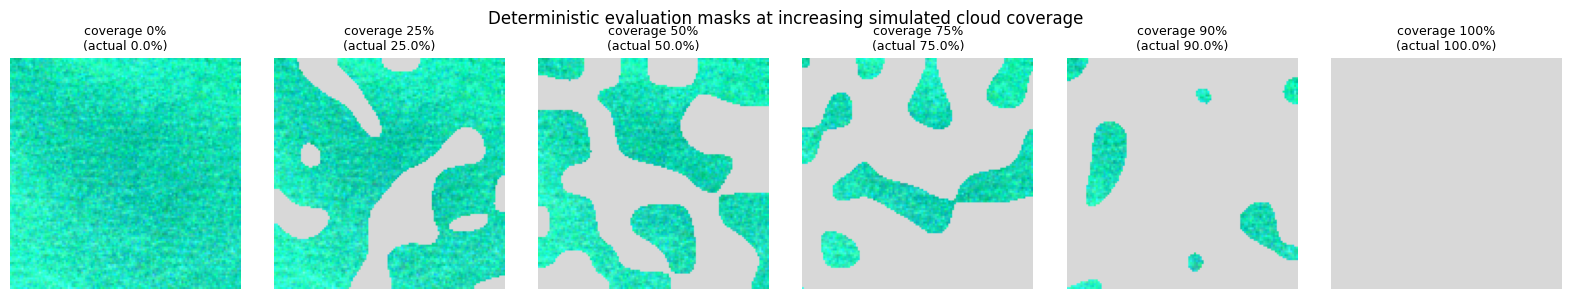

In [9]:
def cloud_mask(coverage, rng, size=PATCH, cells=8):
    if coverage <= 0: return np.zeros((size, size), bool)
    if coverage >= 1: return np.ones((size, size), bool)
    noise = ndimage.zoom(rng.standard_normal((cells, cells)), size / cells, order=3)
    return noise >= np.quantile(noise, 1 - coverage)

def eval_mask(level_i, patch_i):
    return cloud_mask(MASK_LEVELS[level_i], np.random.default_rng((SEED, level_i, int(patch_i))))

i = split_idx['test'][0]
fig, axes = plt.subplots(1, len(MASK_LEVELS), figsize=(16, 3))
for li, ax in enumerate(axes):
    m = eval_mask(li, i)
    im = rgb(i).copy(); im[m] = 0.85
    ax.imshow(im); ax.set_title(f'coverage {MASK_LEVELS[li]:.0%}\n(actual {m.mean():.1%})', fontsize=9)
    ax.axis('off')
plt.suptitle('Deterministic evaluation masks at increasing simulated cloud coverage')
plt.tight_layout(); plt.savefig(FIG_DIR / 'masks.png', dpi=120); plt.show()


## 6. Batching & degradation pipeline

Simple main-process batching straight from the memmaps (Windows-friendly, and the CNN is small
enough that the GPU, not I/O, is the bottleneck). Standardisation and masking happen per batch.


In [10]:
def make_batch(ids, mask_spec, use_sar, train_rng=None):
    """mask_spec: None=clean | int=eval level index (deterministic) | 'random'=train augmentation."""
    xo = torch.from_numpy(X_opt[ids].astype(np.float32))
    xo = (xo - OPT_MEAN) / OPT_STD
    if mask_spec is not None:
        for j, pi in enumerate(ids):
            if mask_spec == 'random':
                if train_rng.random() < 0.5:
                    continue
                m = cloud_mask(train_rng.uniform(0.1, 0.95), train_rng)
            else:
                m = eval_mask(mask_spec, pi)
            xo[j, :, torch.from_numpy(m)] = 0.0
    if use_sar:
        xs = torch.from_numpy(X_sar[ids].astype(np.float32))
        xs = (xs - SAR_MEAN) / SAR_STD
        xo = torch.cat([xo, xs], 1)                     # SAR is never masked
    return xo

def batches(ids, bs, shuffle=False, rng=None):
    ids = ids.copy()
    if shuffle: rng.shuffle(ids)
    for k in range(0, len(ids), bs):
        yield ids[k:k + bs]


## 7. Model — a deliberately simple CNN

Four conv blocks (32→64→128→256, BN+ReLU+MaxPool), global average pooling, dropout, linear
head with sigmoid outputs (BCE loss). ~1.6 M parameters. The **same architecture** is used for
all conditions; only `in_ch` differs (12 vs 14).


In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, in_ch, n_classes=NC):
        super().__init__()
        layers, c = [], in_ch
        for out in [32, 64, 128, 256]:
            layers += [nn.Conv2d(c, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU(inplace=True),
                       nn.Conv2d(out, out, 3, padding=1), nn.BatchNorm2d(out), nn.ReLU(inplace=True),
                       nn.MaxPool2d(2)]
            c = out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(c, n_classes))
    def forward(self, x): return self.head(self.features(x))

print(sum(p.numel() for p in SimpleCNN(12).parameters()) / 1e6, 'M params')


1.179595 M params


## 8. Training

Three models, identical regime (AdamW, cosine schedule, BCE with class-balancing `pos_weight`,
mixed precision, best-val-macro-F1 checkpointing):

- **model_A** — optical, trained clean (the minimum baseline).
- **model_B** — optical, trained with random mask augmentation (fair degraded-optical model).
- **model_C** — optical+SAR, trained with the *same* mask augmentation on optical only.

Validation metric: macro-F1 on the validation split at 50% deterministic coverage for B/C
(their target regime), clean for A.


In [12]:
pos = Y[split_idx['train']].mean(0)
POS_WEIGHT = torch.tensor(np.clip((1 - pos) / pos, 1.0, 10.0), dtype=torch.float32, device=DEVICE)
print(pd.DataFrame({'class': CLASSES, 'train_pos_rate': pos.round(3), 'pos_weight': POS_WEIGHT.cpu().numpy().round(2)}))

@torch.no_grad()
def predict(model, ids, mask_spec, use_sar, bs=256):
    model.eval(); out = []
    for b in batches(ids, bs):
        x = make_batch(b, mask_spec, use_sar).to(DEVICE, non_blocking=True)
        with torch.autocast('cuda', enabled=DEVICE.type == 'cuda'):
            out.append(torch.sigmoid(model(x)).float().cpu())
    return torch.cat(out).numpy()

def macro_f1(y, p, thr=0.5): return f1_score(y, p >= thr, average='macro', zero_division=0)

def train_model(name, use_sar, mask_train, val_mask_spec, epochs=EPOCHS):
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = SimpleCNN(14 if use_sar else 12).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler(enabled=DEVICE.type == 'cuda')
    crit = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    tr, va = split_idx['train'], split_idx['validation']
    rng = np.random.default_rng(SEED)
    best_f1, best_state, hist = -1, None, []
    for ep in range(epochs):
        model.train(); losses = []; t0 = time.time()
        for b in batches(tr, BATCH, shuffle=True, rng=rng):
            x = make_batch(b, 'random' if mask_train else None, use_sar, train_rng=rng).to(DEVICE)
            yb = torch.from_numpy(Y[b]).to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast('cuda', enabled=DEVICE.type == 'cuda'):
                loss = crit(model(x), yb)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            losses.append(loss.item())
        sched.step()
        vf1 = macro_f1(Y[va], predict(model, va, val_mask_spec, use_sar))
        hist.append({'epoch': ep, 'loss': float(np.mean(losses)), 'val_macro_f1': vf1})
        if vf1 > best_f1: best_f1, best_state = vf1, {k: v.clone() for k, v in model.state_dict().items()}
        print(f'[{name}] ep {ep + 1:02d}/{epochs}  loss {np.mean(losses):.4f}  val mF1 {vf1:.4f}  ({time.time() - t0:.0f}s)')
    model.load_state_dict(best_state)
    pd.DataFrame(hist).to_csv(PROC_DIR / f'{name}_history.csv', index=False)
    torch.save(model.state_dict(), PROC_DIR / f'{name}.pt')
    print(f'[{name}] best val macro-F1 = {best_f1:.4f}')
    return model, pd.DataFrame(hist)


                                                class  train_pos_rate  \
0                                        Urban fabric           0.147   
1                                         Arable land           0.408   
2                                            Pastures           0.278   
3                        Complex cultivation patterns           0.465   
4   Land principally occupied by agriculture, with...           0.351   
5                                 Broad-leaved forest           0.215   
6                                   Coniferous forest           0.424   
7                                        Mixed forest           0.440   
8                        Transitional woodland, shrub           0.266   
9                                       Inland waters           0.117   
10                                      Marine waters           0.205   

    pos_weight  
0         5.78  
1         1.45  
2         2.60  
3         1.15  
4         1.85  
5         3.65  
6   

In [13]:
LEVEL50 = MASK_LEVELS.index(0.5)
model_A, hist_A = train_model('model_A_optical_clean', use_sar=False, mask_train=False, val_mask_spec=None)


[model_A_optical_clean] ep 01/30  loss 0.6286  val mF1 0.6944  (35s)


[model_A_optical_clean] ep 02/30  loss 0.5703  val mF1 0.7184  (28s)


[model_A_optical_clean] ep 03/30  loss 0.5536  val mF1 0.7051  (17s)


[model_A_optical_clean] ep 04/30  loss 0.5375  val mF1 0.6897  (16s)


[model_A_optical_clean] ep 05/30  loss 0.5275  val mF1 0.7157  (16s)


...

[model_A_optical_clean] ep 27/30  loss 0.4205  val mF1 0.7541  (21s)


[model_A_optical_clean] ep 28/30  loss 0.4162  val mF1 0.7518  (20s)


[model_A_optical_clean] ep 29/30  loss 0.4119  val mF1 0.7510  (17s)


[model_A_optical_clean] ep 30/30  loss 0.4127  val mF1 0.7535  (17s)


[model_A_optical_clean] best val macro-F1 = 0.7541


In [14]:
model_B, hist_B = train_model('model_B_optical_maskaug', use_sar=False, mask_train=True, val_mask_spec=LEVEL50)


[model_B_optical_maskaug] ep 01/30  loss 0.6684  val mF1 0.6794  (35s)


[model_B_optical_maskaug] ep 02/30  loss 0.5947  val mF1 0.6700  (33s)


[model_B_optical_maskaug] ep 03/30  loss 0.5706  val mF1 0.6998  (33s)


[model_B_optical_maskaug] ep 04/30  loss 0.5585  val mF1 0.7080  (33s)


[model_B_optical_maskaug] ep 05/30  loss 0.5455  val mF1 0.7148  (32s)


...

[model_B_optical_maskaug] ep 26/30  loss 0.4445  val mF1 0.7423  (33s)


[model_B_optical_maskaug] ep 27/30  loss 0.4465  val mF1 0.7455  (35s)


[model_B_optical_maskaug] ep 28/30  loss 0.4435  val mF1 0.7458  (33s)


[model_B_optical_maskaug] ep 29/30  loss 0.4466  val mF1 0.7451  (33s)


[model_B_optical_maskaug] ep 30/30  loss 0.4444  val mF1 0.7434  (32s)
[model_B_optical_maskaug] best val macro-F1 = 0.7458


In [15]:
model_C, hist_C = train_model('model_C_opticalSAR_maskaug', use_sar=True, mask_train=True, val_mask_spec=LEVEL50)


[model_C_opticalSAR_maskaug] ep 01/30  loss 0.6382  val mF1 0.6772  (46s)


[model_C_opticalSAR_maskaug] ep 02/30  loss 0.5813  val mF1 0.6095  (49s)


[model_C_opticalSAR_maskaug] ep 03/30  loss 0.5703  val mF1 0.6952  (42s)


[model_C_opticalSAR_maskaug] ep 04/30  loss 0.5582  val mF1 0.7030  (39s)


[model_C_opticalSAR_maskaug] ep 05/30  loss 0.5455  val mF1 0.6776  (35s)


...

[model_C_opticalSAR_maskaug] ep 26/30  loss 0.4430  val mF1 0.7453  (33s)


[model_C_opticalSAR_maskaug] ep 27/30  loss 0.4412  val mF1 0.7466  (33s)


[model_C_opticalSAR_maskaug] ep 28/30  loss 0.4393  val mF1 0.7465  (35s)


[model_C_opticalSAR_maskaug] ep 29/30  loss 0.4413  val mF1 0.7473  (34s)


[model_C_opticalSAR_maskaug] ep 30/30  loss 0.4397  val mF1 0.7467  (33s)
[model_C_opticalSAR_maskaug] best val macro-F1 = 0.7477


### Training curves

Loss decreases smoothly for all three models. Note two things when reading them:

- **Losses are not directly comparable across models**: B and C compute theirs on randomly masked inputs (a harder objective), so their curves sit above A's.
- **Validation metrics differ by design**: A is validated on clean optical, B/C at deterministic 50% coverage (their target regime). The jagged val curve is normal for a small CNN + BatchNorm; we checkpoint the best-val epoch, not the last.

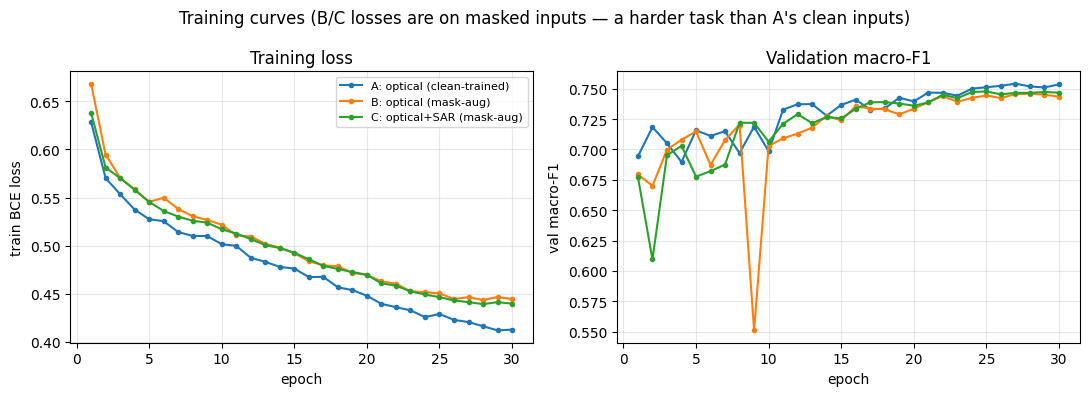

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, label in [('model_A_optical_clean', 'A: optical (clean-trained)'),
                    ('model_B_optical_maskaug', 'B: optical (mask-aug)'),
                    ('model_C_opticalSAR_maskaug', 'C: optical+SAR (mask-aug)')]:
    h = pd.read_csv(PROC_DIR / f'{name}_history.csv')
    axes[0].plot(h['epoch'] + 1, h['loss'], marker='o', ms=3, label=label)
    axes[1].plot(h['epoch'] + 1, h['val_macro_f1'], marker='o', ms=3, label=label)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train BCE loss'); axes[0].set_title('Training loss')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro-F1'); axes[1].set_title('Validation macro-F1')
for ax in axes: ax.grid(alpha=.3)
axes[0].legend(fontsize=8)
plt.suptitle("Training curves (B/C losses are on masked inputs — a harder task than A's clean inputs)")
plt.tight_layout(); plt.savefig(FIG_DIR / 'training_curves.png', dpi=120); plt.show()

## 9. Evaluation — conditions × cloud-coverage levels

Test-split metrics (threshold 0.5, deliberately untuned): **macro-F1** (primary — insensitive to
class imbalance), **mAP** (threshold-free), **micro-F1** and **subset accuracy** (exact match,
the strictest). Every model sees identical masks at each level.


In [17]:
te = split_idx['test']
results, probs_cache = [], {}
evals = [('A: optical (clean-trained)', model_A, False),
         ('B: optical (mask-aug)',      model_B, False),
         ('C: optical+SAR (mask-aug)',  model_C, True)]
for name, model, use_sar in evals:
    for li, lvl in enumerate(tqdm(MASK_LEVELS, desc=name)):
        p = predict(model, te, li if lvl > 0 else None, use_sar)
        probs_cache[(name, lvl)] = p
        results.append({'model': name, 'coverage': lvl,
                        'macro_F1': macro_f1(Y[te], p),
                        'mAP': average_precision_score(Y[te], p, average='macro'),
                        'micro_F1': f1_score(Y[te], p >= 0.5, average='micro', zero_division=0),
                        'subset_acc': float((( p >= 0.5) == Y[te].astype(bool)).all(1).mean())})
res = pd.DataFrame(results)
display(res.pivot(index='coverage', columns='model', values='macro_F1').round(4))
display(res.pivot(index='coverage', columns='model', values='mAP').round(4))
res.to_csv(PROC_DIR / 'results.csv', index=False)


A: optical (clean-trained):   0%|          | 0/6 [00:00<?, ?it/s]

A: optical (clean-trained):  17%|█▋        | 1/6 [00:08<00:42,  8.40s/it]

A: optical (clean-trained):  33%|███▎      | 2/6 [00:20<00:42, 10.68s/it]

A: optical (clean-trained):  50%|█████     | 3/6 [00:32<00:33, 11.20s/it]

A: optical (clean-trained):  67%|██████▋   | 4/6 [00:44<00:23, 11.56s/it]

...

C: optical+SAR (mask-aug):  83%|████████▎ | 5/6 [00:56<00:11, 11.99s/it]

C: optical+SAR (mask-aug): 100%|██████████| 6/6 [01:02<00:00,  9.76s/it]

C: optical+SAR (mask-aug): 100%|██████████| 6/6 [01:02<00:00, 10.40s/it]

model,A: optical (clean-trained),B: optical (mask-aug),C: optical+SAR (mask-aug)
coverage,,,
0.00,0.7528,0.7495,0.7514
0.25,0.7049,0.7461,0.7485
0.50,0.6326,0.7465,0.7412
0.75,0.4116,0.7301,0.7333
0.90,0.2546,0.7144,0.7229
1.00,0.1179,0.3295,0.7111


model,A: optical (clean-trained),B: optical (mask-aug),C: optical+SAR (mask-aug)
coverage,,,
0.00,0.8029,0.8051,0.8029
0.25,0.7891,0.8026,0.7997
0.50,0.7319,0.7952,0.7930
0.75,0.6439,0.7793,0.7805
0.90,0.5417,0.7530,0.7625
1.00,0.3605,0.3605,0.7344


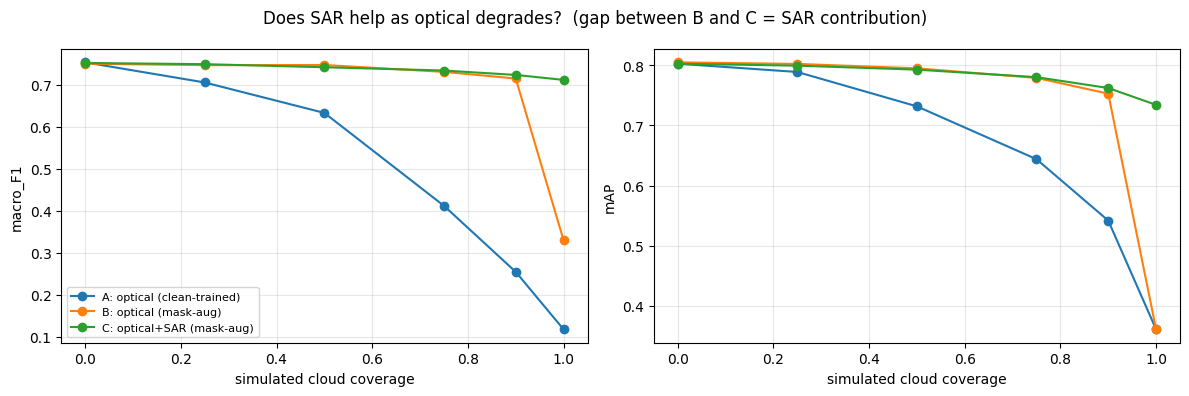

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for metric, ax in zip(['macro_F1', 'mAP'], axes):
    for name, g in res.groupby('model'):
        ax.plot(g['coverage'], g[metric], marker='o', label=name)
    ax.set_xlabel('simulated cloud coverage'); ax.set_ylabel(metric); ax.grid(alpha=.3)
axes[0].legend(fontsize=8)
plt.suptitle('Does SAR help as optical degrades?  (gap between B and C = SAR contribution)')
plt.tight_layout(); plt.savefig(FIG_DIR / 'coverage_curves.png', dpi=120); plt.show()


### Per-class effect of SAR at heavy degradation (75% coverage)

Where does SAR help most? Per-class F1 for B vs C.


,class,F1_B,F1_C,delta_C_minus_B,test_support
6,Coniferous forest,0.853,0.835,-0.018,1193
2,Pastures,0.720,0.707,-0.013,916
0,Urban fabric,0.499,0.495,-0.004,265
1,Arable land,0.749,0.746,-0.002,883
5,Broad-leaved forest,0.538,0.538,-0.000,511
10,Marine waters,1.000,1.000,0.000,116
8,"Transitional woodland, shrub",0.604,0.607,0.003,885
3,Complex cultivation patterns,0.810,0.818,0.008,1172
7,Mixed forest,0.794,0.803,0.009,1214
4,"Land principally occupied by agriculture, with...",0.724,0.735,0.010,996


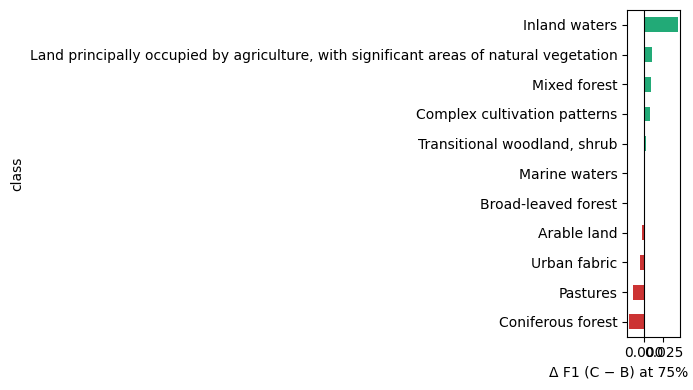

In [19]:
LEVEL75 = MASK_LEVELS.index(0.75)
pB = probs_cache[('B: optical (mask-aug)', 0.75)]
pC = probs_cache[('C: optical+SAR (mask-aug)', 0.75)]
f1B = f1_score(Y[te], pB >= 0.5, average=None, zero_division=0)
f1C = f1_score(Y[te], pC >= 0.5, average=None, zero_division=0)
per_class = pd.DataFrame({'class': CLASSES, 'F1_B': f1B.round(3), 'F1_C': f1C.round(3),
                          'delta_C_minus_B': (f1C - f1B).round(3),
                          'test_support': Y[te].sum(0).astype(int)}).sort_values('delta_C_minus_B')
display(per_class)

ax = per_class.plot.barh(x='class', y='delta_C_minus_B', figsize=(7, 4), legend=False,
                         color=np.where(per_class['delta_C_minus_B'] >= 0, '#2a7', '#c33'))
ax.set_xlabel('Δ F1 (C − B) at 75% coverage'); ax.axvline(0, color='k', lw=.8)
plt.tight_layout(); plt.savefig(FIG_DIR / 'per_class_delta.png', dpi=120); plt.show()


### Representative successes and failures (75% coverage)

- **SAR rescues** — patches where C's prediction set is exactly right and B's is wrong.
- **Both fail** — residual failure cases even with SAR.

Shown: masked optical RGB as the models see it (grey = masked), full RGB for reference, SAR VV.


exact-match at 75% cover: B 11.1%, C 11.2% | rescued by SAR: 58 | both fail: 1854


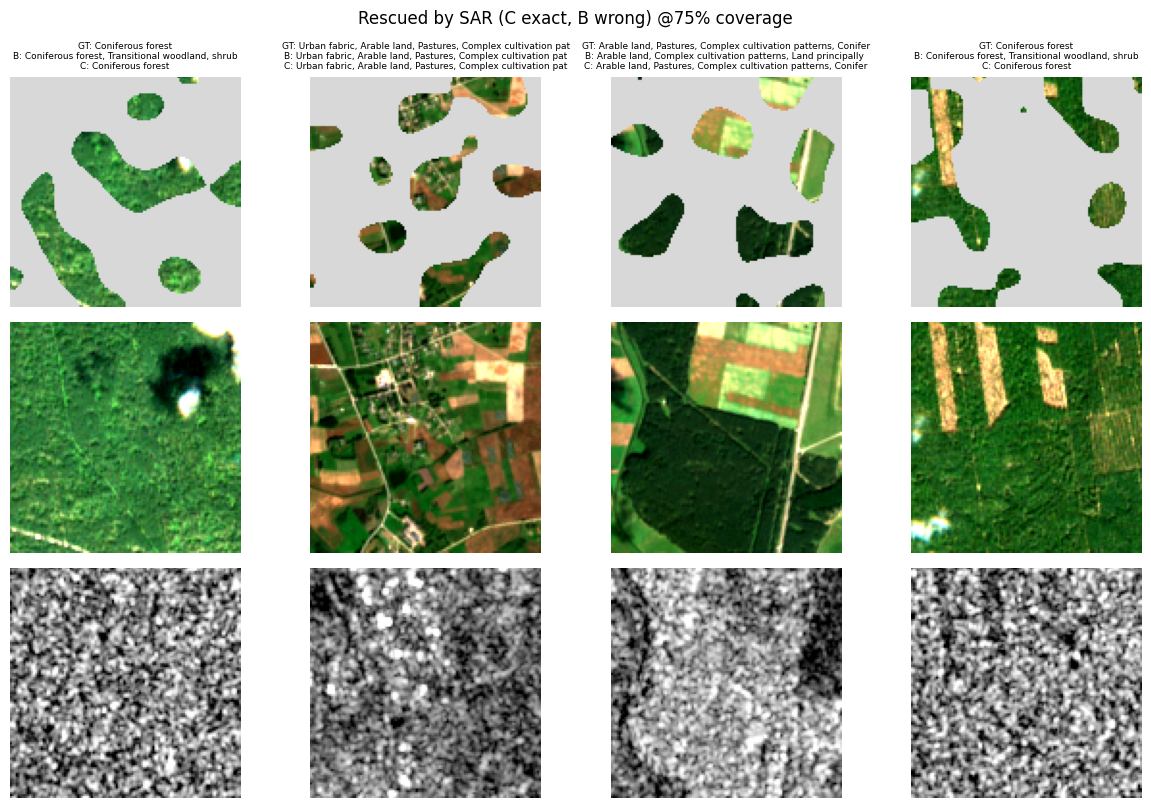

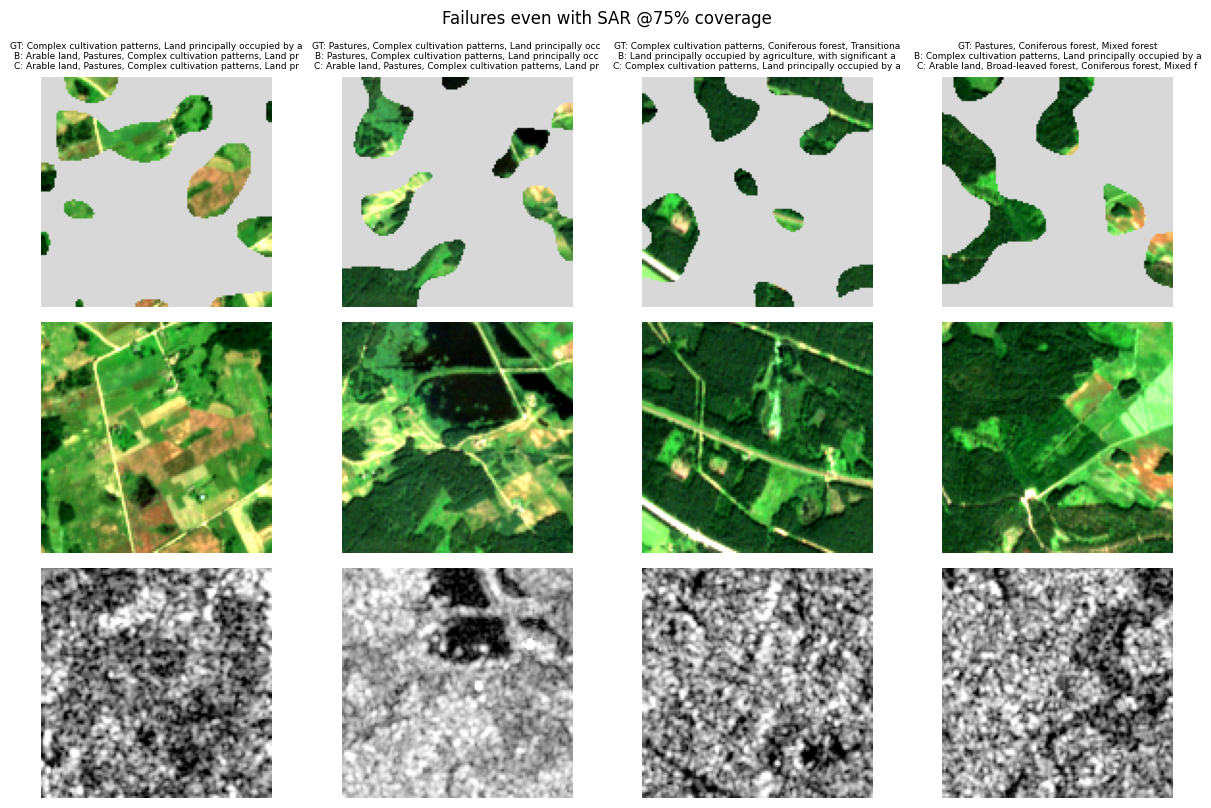

In [20]:
yb_hat, yc_hat = pB >= 0.5, pC >= 0.5
yt = Y[te].astype(bool)
exactB, exactC = (yb_hat == yt).all(1), (yc_hat == yt).all(1)
rescued   = np.where(exactC & ~exactB)[0]
both_fail = np.where(~exactC & ~exactB)[0]
print(f'exact-match at 75% cover: B {exactB.mean():.1%}, C {exactC.mean():.1%} | '
      f'rescued by SAR: {len(rescued)} | both fail: {len(both_fail)}')

def show_cases(case_ids, title, n=4):
    rng = np.random.default_rng(SEED)
    pick = rng.choice(case_ids, min(n, len(case_ids)), replace=False)
    fig, axes = plt.subplots(3, len(pick), figsize=(3.1 * len(pick), 8.2))
    axes = axes.reshape(3, -1)
    for j, k in enumerate(pick):
        gi = te[k]; m = eval_mask(LEVEL75, gi)
        im = rgb(gi).copy(); im[m] = 0.85
        axes[0, j].imshow(im); axes[1, j].imshow(rgb(gi)); axes[2, j].imshow(sar_img(gi), cmap='gray')
        fmt = lambda v: ', '.join(np.array(CLASSES)[v] if v.any() else ['-'])[:60]
        axes[0, j].set_title(f'GT: {fmt(yt[k])}\nB: {fmt(yb_hat[k])}\nC: {fmt(yc_hat[k])}', fontsize=6.5)
        for ax in axes[:, j]: ax.axis('off')
    for r, lab in enumerate(['masked S2 (model input)', 'clean S2 (reference)', 'S1 VV']):
        axes[r, 0].set_ylabel(lab, fontsize=8)
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(FIG_DIR / f'{title.split()[0].lower()}_cases.png', dpi=120); plt.show()

if len(rescued):   show_cases(rescued, 'Rescued by SAR (C exact, B wrong) @75% coverage')
if len(both_fail): show_cases(both_fail, 'Failures even with SAR @75% coverage')


## 10. Discussion

*(Numbers below are from the 30-epoch run; the earlier 14-epoch run is kept in
`data/processed/results_14ep.csv` and used as an informal run-to-run variance check.)*

### Headline results (test macro-F1, 30 epochs)

| coverage | A: clean-trained | B: mask-aug | C: +SAR | Δ (C−B) |
|---|---|---|---|---|
| 0% | 0.753 | 0.750 | 0.751 | +0.002 |
| 50% | 0.633 | 0.747 | 0.741 | −0.005 |
| 75% | 0.412 | 0.730 | 0.733 | +0.003 |
| 90% | 0.255 | 0.714 | 0.723 | +0.009 |
| **100%** | 0.118 | 0.330 | **0.711** | **+0.382** |

**Finding 1 — the clean-trained baseline is brittle.** Model A collapses under masking it never
saw in training (0.753 → 0.41 at 75% coverage): this is distribution shift, not information
loss — Model B proves the information is still there.

**Finding 2 — mask augmentation alone recovers most of the loss.** Scene-level labels of a
1.2 × 1.2 km patch are spatially redundant: with only 10% of pixels visible, Model B still
reaches 0.714 macro-F1 (vs 0.750 clean). Partial cloud cover leaves little headroom for SAR.

**Finding 3 — with this simple early fusion, SAR's value is concentrated at (near-)total
optical loss.** At 25–75% coverage the C−B gap is now **within noise** (−0.5 to +0.3 pts,
changing sign between the 14- and 30-epoch runs); at 90% a small +0.9 pt gain appears, and at
100% SAR is decisive: 0.711 vs 0.330 — SAR alone retains ~94% of clean-optical performance
while the optical-only model falls to label-prior guessing. SAR here is *insurance against
fully overcast scenes* rather than a booster under partial clouds.

**Finding 4 — where SAR helps (per-class, 75% coverage).** Consistent gains only for
Inland waters (+4.3 F1; specular water = distinctively low backscatter) and small gains on the
agriculture mosaics (+0.8–1.0); consistent small losses on Coniferous forest (−1.8) and
Pastures (−1.3), where C-band VV/VH separates vegetation types poorly and the extra channels
add noise. Marine waters is saturated at F1 = 1.0 for both models at every coverage level —
an easy class that inflates macro averages.

**Uncertainty.** Comparing the 14- and 30-epoch runs gives a feel for training variance:
individual cells moved by 1–2 macro-F1 points, the same order as the mid-coverage B–C gaps —
which is why we do not claim a SAR benefit at 25–75% coverage without bootstrap confidence
intervals and seed replicates (next step #1). The 100%-coverage gap (+38 pts) and Model A's
collapse are far beyond any plausible noise band. At 75% coverage C exactly matches the full
label set on 11.2% of test patches vs 11.1% for B (58 patches rescued by SAR, 32 lost);
1,854 patches fail under both models — dominated by fine-grained agriculture/forest
confusions where the scene-level CORINE labels are ambiguous even in clean imagery.

### Threats to validity we controlled for
- **Paired evaluation**: identical deterministic masks per patch across all models and levels.
- **No leakage**: official reBEN splits; normalisation stats from train only; no threshold tuning.
- **Fair B vs C**: same architecture/seed/regime — the only delta is the two SAR channels.

### Known limitations
- Simulated masks (value = band mean) approximate *thick* clouds; thin/semi-transparent cloud,
  haze and cloud shadows corrupt rather than remove signal — a harder, more realistic setting.
- Scene-level noisy labels (CORINE-derived); single country/season subset limits generality.
- No explicit mask channel: models must infer what is missing.
- Early channel-concat fusion forces 2 SAR channels to compete with 12 optical channels in the
  first convolution — a plausible reason SAR contributes nothing at partial coverage.

### What I would try next
1. **Bootstrap CIs + seed replicates** to put error bars on every gap (cheap, highest value).
2. **Dual-encoder late fusion** — separate SAR/optical encoders so SAR features specialise
   instead of being drowned by optical channels; most likely fix for the mid-coverage regime.
3. Give the model the **mask as an explicit input channel** (cheap, usually helps mid-coverage).
4. **Cross-modal distillation**: regress SAR features onto clean-optical features so the SAR
   branch learns optical-like semantics for the fully-clouded case.
5. Pretrained remote-sensing backbones (SSL4EO / BigEarthNet-pretrained encoders).
6. **Real cloud degradation** (overlay actually-cloudy Sentinel-2 acquisitions) instead of blobs.
7. Scale to the full 19-class reBEN dataset across countries/seasons.
